In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, ShuffleSplit
import random

# Set random seed for reproducibility
np.random.seed(0)
random.seed(0)
seed=0

# Load data and preprocess it
def load_CSN_data():
    csv_path = '../Master_List_LCPLCP.csv'
    return pd.read_csv(csv_path)

CSN = load_CSN_data()

CSN = CSN.drop(['Example ID', 'Source', 'Figure ID', 'Data Provider', 'PI',
                'Date Received', 'Data Measurment Published', 'Prior Exposure', 'Comments', 'Error'], axis=1)

CSN_prepared = pd.get_dummies(CSN, dtype=int)
CSN_prepared['Surface Area per Liter'] = CSN_prepared['Surface Area (NMC) (m2/g)'] * CSN_prepared['Concentration (mg/L)']
CSN_prepared = CSN_prepared.drop(['Surface Area (NMC) (m2/g)'], axis=1)
CSN_prepared['log Concentration'] = np.log10(CSN_prepared['Concentration (mg/L)'] + 1e-9)
CSN_prepared = CSN_prepared.drop(['Concentration (mg/L)'], axis=1)

CSN_new= CSN_prepared[-18:]
CSN_prepared = CSN_prepared[:-18]
X_train = CSN_prepared.drop(['Viability Fraction '], axis=1)
Y_train = CSN_prepared['Viability Fraction ']

X_test = CSN_new.drop(['Viability Fraction '], axis=1)
Y_test = CSN_new['Viability Fraction ']

In [2]:
# Define parameter grids for each model
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
}

gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1],
}

adaboost_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1],
}

xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1],
}

# Initialize models
models = {
    'Random Forest': (RandomForestRegressor(random_state=seed), rf_param_grid),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=seed), gb_param_grid),
    'AdaBoost': (AdaBoostRegressor(random_state=seed), adaboost_param_grid),
    # Note: use_label_encoder=False and eval_metric='mae' for XGBoost are specific settings
    'XGBoost': (XGBRegressor(random_state=seed, use_label_encoder=False, eval_metric='mae'), xgb_param_grid), 
}

# Define cross-validation strategies
cv_methods = {
    'KFold': KFold(n_splits=4),
    'KFold-Shuffle': KFold(n_splits=4, shuffle=True, random_state=seed),
    # MCCV stands for Monte Carlo Cross-Validation (ShuffleSplit)
    'MCCV': ShuffleSplit(n_splits=4, test_size=0.25, random_state=seed),
    'Random MCCV': ShuffleSplit(n_splits=4, test_size=random.uniform(0.1, 0.25), random_state=seed)
}

# --- MODIFIED RESULT STORAGE ---

# List to store every single MAE result (Seed, Model, Method, Fold, MAE)
all_run_mae_results = []

# Loop over seeds
num_seeds = 10
for seed in range(num_seeds):
    print(f"Seed: {seed}")
    # Set seeds for reproducibility across runs
    random.seed(seed)
    np.random.seed(seed)
    
    for model_name, (model, param_grid) in models.items():
        # Perform Grid Search with Cross-Validation (CV=4 on X_train)
        # Scoring uses 'neg_mean_absolute_error' to find the minimum MAE
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=4, scoring='neg_mean_absolute_error', verbose=0, n_jobs=-1)
        grid_search.fit(X_train, Y_train)

        # Use the best estimator found by GridSearch
        best_model = grid_search.best_estimator_

        # Evaluate model with different cross-validation strategies
        for method_name, cv_method in cv_methods.items():
            print(f"Evaluating: {model_name} with {method_name} and seed {seed}")
            X_train_full, Y_train_full = X_train, Y_train
            
            fold_counter = 0 # Track the current fold within the CV method
            
            # Iterate through the folds defined by the cross-validation method
            for train_index, _ in cv_method.split(X_train_full):
                X_train_fold = X_train_full.iloc[train_index]
                Y_train_fold = Y_train_full.iloc[train_index]
                
                # Re-train the best model on the training fold subset
                best_model.fit(X_train_fold, Y_train_fold)
                
                # Predict on the fixed external test set (X_test)
                Y_test_pred = best_model.predict(X_test)
                
                # Calculate MAE on the fixed external test set
                test_mae = mean_absolute_error(Y_test, Y_test_pred)
                
                # Store the detailed result for this specific run and fold
                all_run_mae_results.append({
                    'Seed': seed,
                    'Model': model_name,
                    'CV_Method': method_name,
                    'Fold': fold_counter,
                    'MAE': test_mae
                })
                
                fold_counter += 1

# Convert the list of detailed results to a DataFrame
results_df = pd.DataFrame(all_run_mae_results)

# Save the results
results_df.to_csv('standard_method_test_10_results.csv', index=False)

# --- Compute average results (optional, but kept for compatibility) ---

# Compute the mean MAE across all seeds and folds for each Model/CV_Method combination
average_results = results_df.groupby(['Model', 'CV_Method'])['MAE'].mean().unstack()

Seed: 0
Evaluating: Random Forest with KFold and seed 0
Evaluating: Random Forest with KFold-Shuffle and seed 0
Evaluating: Random Forest with MCCV and seed 0
Evaluating: Random Forest with Random MCCV and seed 0
Evaluating: Gradient Boosting with KFold and seed 0
Evaluating: Gradient Boosting with KFold-Shuffle and seed 0
Evaluating: Gradient Boosting with MCCV and seed 0
Evaluating: Gradient Boosting with Random MCCV and seed 0
Evaluating: AdaBoost with KFold and seed 0
Evaluating: AdaBoost with KFold-Shuffle and seed 0
Evaluating: AdaBoost with MCCV and seed 0
Evaluating: AdaBoost with Random MCCV and seed 0
Evaluating: XGBoost with KFold and seed 0
Evaluating: XGBoost with KFold-Shuffle and seed 0
Evaluating: XGBoost with MCCV and seed 0
Evaluating: XGBoost with Random MCCV and seed 0
Seed: 1
Evaluating: Random Forest with KFold and seed 1
Evaluating: Random Forest with KFold-Shuffle and seed 1
Evaluating: Random Forest with MCCV and seed 1
Evaluating: Random Forest with Random MCC

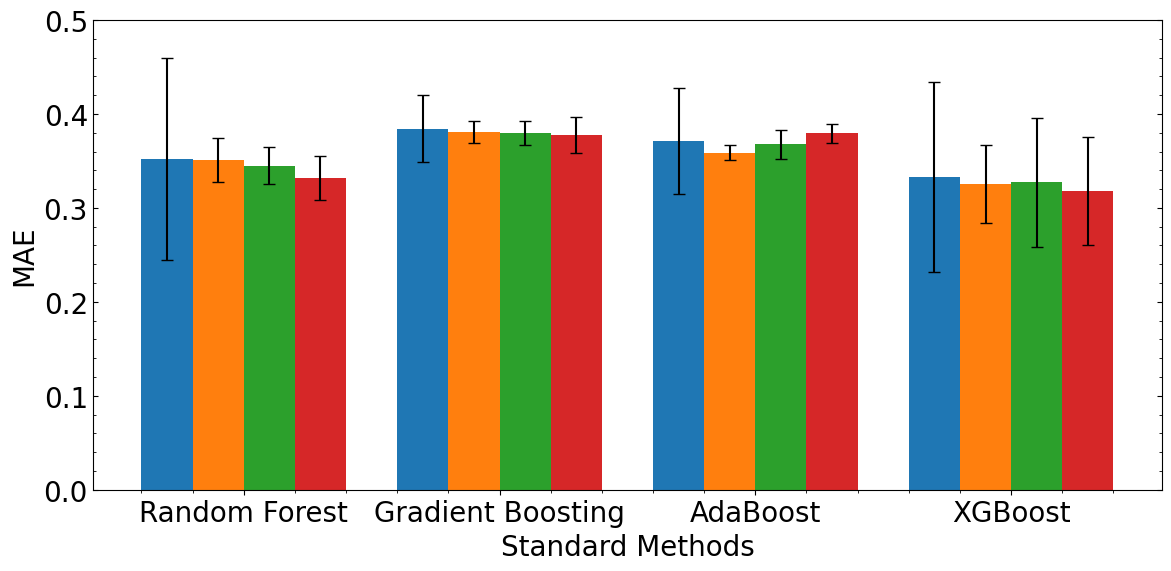

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, ShuffleSplit
import random

#### Font Sizing
#SMALL_SIZE =12
#MEDIUM_SIZE = 15
#BIGGER_SIZE = 18
SMALL_SIZE =16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
#### 

# Set random seed for reproducibility
np.random.seed(0)
random.seed(0)
seed=0

# Define parameter grids for each model (placeholder)
rf_param_grid = {}
gb_param_grid = {}
adaboost_param_grid = {}
xgb_param_grid = {}
catboost_param_grid = {}

# Initialize models
models = {
    'Random Forest': (RandomForestRegressor(random_state=seed), rf_param_grid),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=seed), gb_param_grid),
    'AdaBoost': (AdaBoostRegressor(random_state=seed), adaboost_param_grid),
    'XGBoost': (XGBRegressor(random_state=seed, use_label_encoder=False, eval_metric='mae'), xgb_param_grid),
}

# Define cross-validation strategies
cv_methods = {
    'KFold': KFold(n_splits=4),
    'KFold-Shuffle': KFold(n_splits=4, shuffle=True, random_state=seed),
    'MCCV': ShuffleSplit(n_splits=4, test_size=0.25, random_state=seed),
    'Random MCCV': ShuffleSplit(n_splits=4, test_size=random.uniform(0.1, 0.25), random_state=seed)
}

# Load the DETAILED results (all runs)
results_df = pd.read_csv('standard_method_test_10_results.csv')
#results_df = pd.read_csv('standard_method_val_10_results.csv')

# Calculate mean and standard deviation from the detailed results
# Group by Model and CV_Method to get stats
grouped_results = results_df.groupby(['Model', 'CV_Method'])['MAE']
average_results = grouped_results.mean().unstack()
std_dev_results = grouped_results.std().unstack()

# Re-order rows and columns to match the defined dictionary orders
average_results = average_results.reindex(index=models.keys(), columns=cv_methods.keys())
std_dev_results = std_dev_results.reindex(index=models.keys(), columns=cv_methods.keys())


# Plot bar chart for each algorithm
fig = plt.figure(figsize=(12, 6))
plt.rcParams["mathtext.fontset"] = "cm"
bar_width = 0.20
index = np.arange(len(models)) # index based on number of models

# Iterate through each CV method to plot its bars
for i, method_name in enumerate(cv_methods.keys()):
    # Get mean scores (bar heights) for all models for this CV method
    avg_scores = average_results[method_name]
    
    # Get standard deviation (error bar size) for all models for this CV method
    std_scores = std_dev_results[method_name]
    
    # Plot bars with error bars (yerr)
    bars = plt.bar(index + i * bar_width, 
                   avg_scores, 
                   bar_width, 
                   label=method_name, 
                   yerr=std_scores, 
                   capsize=4) # capsize adds the small caps to the error bars
    
'''
    # (Data labels removed)
    # # Add data labels
    # for bar in bars:
    #     yval = bar.get_height()
    #     # Adjust text position slightly higher to avoid clash with error bar cap
    #     plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.3f}', 
    #              ha='center', va='bottom', fontsize=10) # Reduced fontsize
'''

plt.xlabel('Standard Methods')
plt.ylabel('MAE')

plt.minorticks_on()
plt.tick_params(axis='y', left=True, right=True, direction='in', which='both')


plt.ylim(0, 0.5)  # Set y-axis limits for better visibility
plt.yticks(np.arange(0, 0.6, 0.1))
#plt.title('Average Test Errors for Different Algorithms and CV Strategies')

# Set x-axis ticks to be in the middle of the group of bars for each model
plt.xticks(index + bar_width * (len(cv_methods) - 1) / 2, models.keys(), rotation=0)

#plt.legend(loc='upper right', frameon=False)  # Remove legend border
plt.tight_layout()
# Save to a new file name to reflect the addition of error bars
plt.savefig('standard_method_test_10_average_results_with_errorbars.pdf', dpi=300)  
plt.show()